## import necessary packages

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.optim as optim
import cv2
from tqdm.notebook import trange, tqdm
import random
from tqdm.auto import tqdm

import time

import sys, os
BASE = os.getcwd()  
if BASE not in sys.path:
    sys.path.append(BASE)
    
sys.path.append('../')
from funcs import *  

In [2]:
def setup_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
setup_seed(42)
DEVICE = 'cuda'
n_pts = 928
pattern_shape = 768
obj = 'Box'

## setting # sampling points

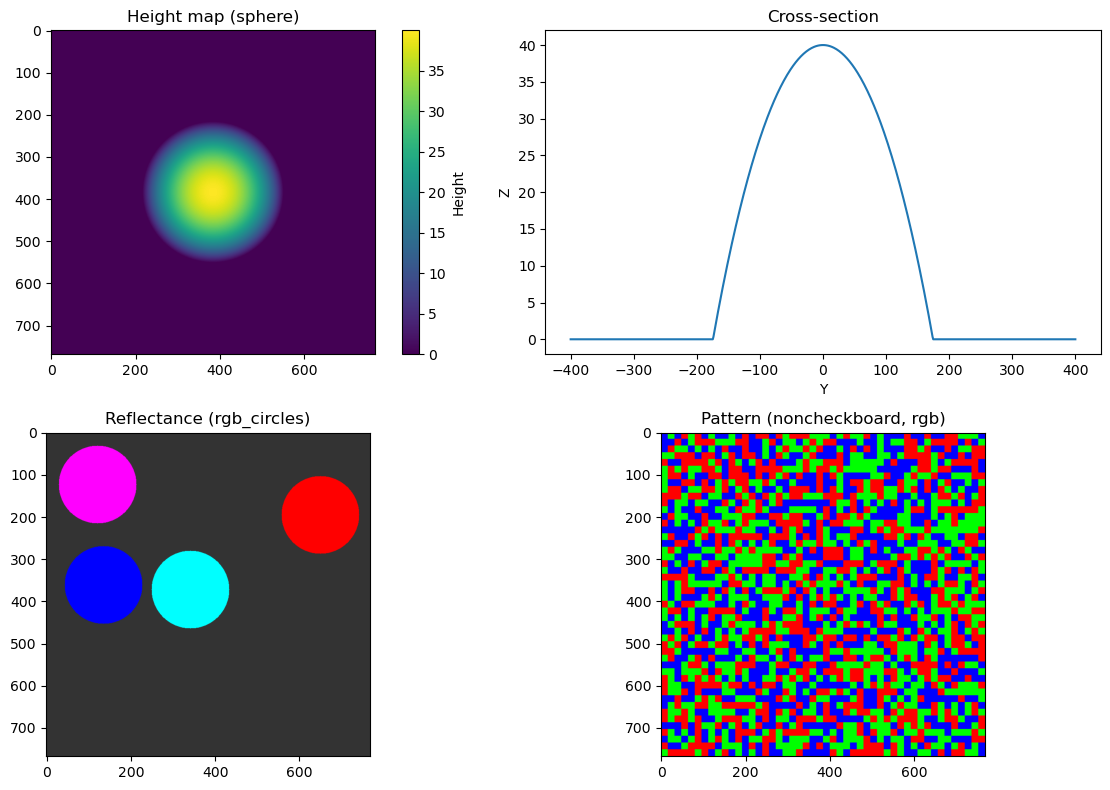

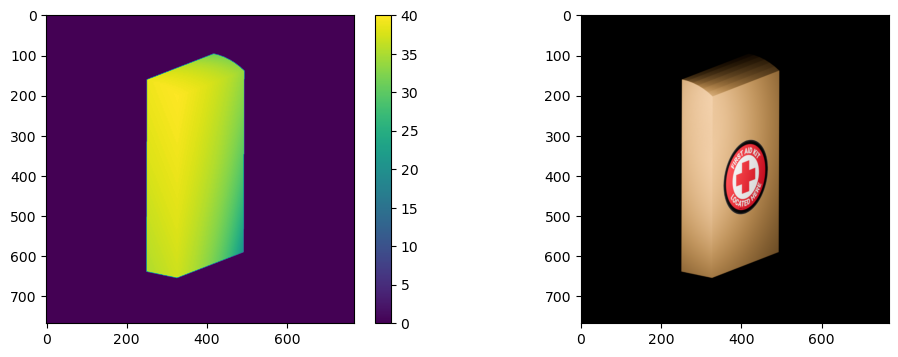

In [3]:
height_map, reflectance, pattern = generate_test_data(pattern_shape, square_size = 16, obj_source="sphere", 
                                                      pattern_source = "noncheckboard" , 
                                                      pattern_mode="rgb",
                                                      reflectance_mode="rgb_circles")
file_path = '../Blender_test/'
relf_path = 'reflectance.png'
heig_path = 'heightmap.png'

# # --- height ---
height_np = cv2.imread(file_path + heig_path, cv2.IMREAD_GRAYSCALE)  # (H,W)
height_np = cv2.resize(height_np, (n_pts, n_pts))
height_np = height_np.astype(np.float32)
height_np = (height_np / (height_np.max() + 1e-12)) * 40.0

height_map = pad_to_size(torch.from_numpy(height_np), (int(pattern_shape*1.5), int(pattern_shape*1.5))).to(torch.float32)

# cv2.resize needs numpy
height_map_np = height_map.cpu().numpy()  # (H,W), float32
height_map_np = cv2.resize(height_map_np, (pattern_shape, pattern_shape), interpolation=cv2.INTER_LINEAR)

# back to torch
height_map = torch.from_numpy(height_map_np).to(torch.float32)
# height_map = height_map.to(device)

# --- reflectance ---
refl_np = cv2.imread(file_path + relf_path)          # (H, W, 3), BGR, uint8
refl_np = cv2.cvtColor(refl_np, cv2.COLOR_BGR2RGB)  # (H, W, 3), RGB
refl_np = cv2.resize(refl_np, (n_pts, n_pts))
refl_np = refl_np.astype(np.float32)


refl_np = refl_np / (refl_np.max() + 1e-12)          # (H, W, 3)

# ========== padding ==========
refl_pad = pad_to_size(
    torch.from_numpy(refl_np),                       # (H, W, 3)
    (int(pattern_shape * 1.5), int(pattern_shape * 1.5))
).numpy()                                            # (H2, W2, 3)

# ========== resize ==========
refl_pad = cv2.resize(
    refl_pad,
    (pattern_shape, pattern_shape),
    interpolation=cv2.INTER_LINEAR
)                                                    # (H, W, 3)

# ========== back to torch, channel-first ==========
reflectance = torch.from_numpy(refl_pad) \
    .permute(2, 0, 1) \
    .to(torch.float32)                               # (3, H, W)


# height_map = torch.rot90(height_map, k = 2,dims = (0,1))/height_map.max()*100
plt.figure(figsize = (12,4))
plt.subplot(121)
plt.imshow(height_map)
plt.colorbar()
plt.subplot(122)
plt.imshow(reflectance.permute(1,2,0))
plt.show()

## if use blender object refletance and height

In [4]:
calib_results = utils.json_loader(file_path=f'../Real_data/{obj}/{obj}_final_calibration_summary.json')
cam_COP = calib_results['camera_position_world']
cam_R = calib_results['R_world_to_camera']
cam_K = calib_results['camera_intrinsic']
proj_COP = calib_results['projector_position_world']
proj_R = calib_results['R_world_to_projector']
proj_K = calib_results['projector_intrinsic']

Projector focal (fx, fy): (2405.9962372020145, 2503.0073079538874)
Projector principal point offset (Δx, Δy): (13.869208331625885, 261.2089887642941)
Camera focal (fx, fy): (4550.583332930169, 4560.969653462267)
Camera principal point offset (Δx, Δy): (62.9898496654705, -70.75718807479461)


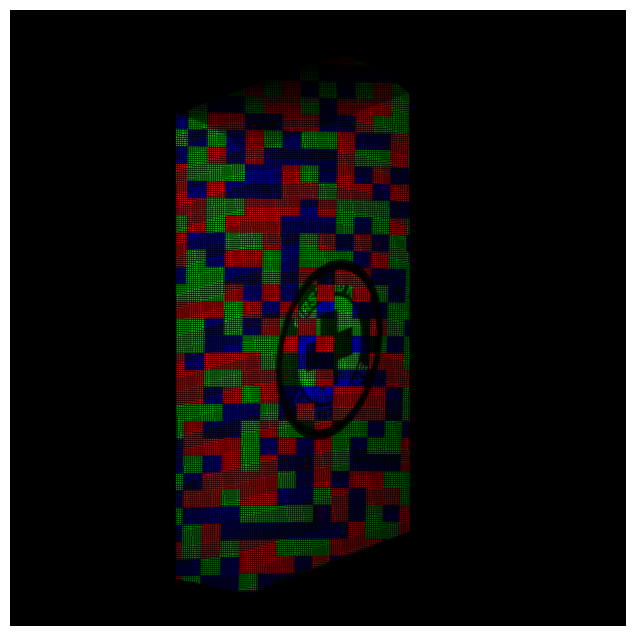

In [5]:
proj_t = -proj_R @ proj_COP
cam_t = -cam_R @ cam_COP


cam_res = (n_pts, n_pts)   
proj_res = (pattern_shape, pattern_shape)  

intrinsics_para = parse_intrinsics(cam_K, proj_K, cam_res, proj_res)

print("Projector focal (fx, fy):", intrinsics_para["projector"]["focal"])
print("Projector principal point offset (Δx, Δy):", intrinsics_para["projector"]["offset"])
print("Camera focal (fx, fy):", intrinsics_para["camera"]["focal"])
print("Camera principal point offset (Δx, Δy):", intrinsics_para["camera"]["offset"])


proj_sensor_size = min(proj_res)
proj_fx, proj_fy = intrinsics_para["projector"]["focal"]   # (fx, fy)
proj_cx_px, proj_cy_px = intrinsics_para["projector"]["offset"]

cam_sensor_size = min(cam_res)
cam_fx,  cam_fy  = intrinsics_para["camera"]["focal"]      # (fx, fy)
cam_cx_px, cam_cy_px = intrinsics_para["camera"]["offset"]
     
    
extent_mm = [-200, 200, -200, 200]   

# Plane coefficients
A = 0.014215
B = 0.008262
C =  0.999865
D = 0.949929

# Extent in mm
xmin, xmax, ymin, ymax = extent_mm

# Resolution
num = proj_res  # 

# Create meshgrid (PyTorch)
x = torch.linspace(xmin, xmax, num[0])
y = torch.linspace(ymin, ymax, num[1])

X, Y = torch.meshgrid(x, y, indexing="xy")  

# Compute Z(x,y)
height_map_whiteboard = -(A * X + B * Y + D) / C

# cam_resolution = 3036
cam_resolution = n_pts
num_photons = None

measured_img = torch.zeros((pattern.shape[0], n_pts, n_pts))[None,:,:,:].to(DEVICE)
imager2 = Proj_Cam_model_ablation(
    proj_f=(proj_fx, proj_fy),
    cam_f=(cam_fx, cam_fy),

    proj_sensor_w_px=proj_sensor_size,
    proj_sensor_h_px=proj_sensor_size,
    cam_sensor_px=cam_sensor_size,

    proj_R=proj_R, proj_t=proj_t,
    cam_R=cam_R, cam_t=cam_t,

    proj_cx_px=proj_cx_px ,
    proj_cy_px=proj_cy_px ,
    cam_cx_px=cam_cx_px,
    cam_cy_px=cam_cy_px,

    device=DEVICE
)

for pattern_c in range(pattern.shape[0]):
    pattern_proj = pattern[pattern_c,:,:]
    measured_img2 = imager2.render(height_map, reflectance[pattern_c,:,:], pattern_proj,
                                   extent_mm=extent_mm,
                                   photon_count=num_photons, show=0, print_matrix= 0,
                                   cam_res=(cam_resolution, cam_resolution), 
                                   use_soft_z_buffer=0, hard_mode = 'zbuffer',
                                   sigma_softz = 0.5, steepness_softz = 200
                                  )
    measured_img[0,pattern_c,:,:] = measured_img2.squeeze()

plt.figure(figsize = (8,8))
plt.imshow(measured_img.squeeze().permute(1,2,0).cpu(),  origin='lower')
plt.axis('off')

plt.show()



## Network

In [6]:
def count_parameters(model, verbose=True):
    total_params = 0
    trainable_params = 0
    total_size_bytes = 0
    trainable_size_bytes = 0

    for p in model.parameters():
        num_params = p.numel()
        param_size = num_params * p.element_size()  # bytes

        total_params += num_params
        total_size_bytes += param_size

        if p.requires_grad:
            trainable_params += num_params
            trainable_size_bytes += param_size

    non_trainable_params = total_params - trainable_params
    non_trainable_size_bytes = total_size_bytes - trainable_size_bytes

    total_size_mb = total_size_bytes / (1024 ** 2)
    trainable_size_mb = trainable_size_bytes / (1024 ** 2)
    non_trainable_size_mb = non_trainable_size_bytes / (1024 ** 2)

    if verbose:
        print("=" * 50)
        print(f"Total parameters:         {total_params:,}")
        print(f"Trainable parameters:     {trainable_params:,}")
        print(f"Non-trainable parameters: {non_trainable_params:,}")
        print("-" * 50)
        print(f"Total model size:         {total_size_mb:.2f} MB")
        print(f"Trainable size:           {trainable_size_mb:.2f} MB")
        print(f"Non-trainable size:       {non_trainable_size_mb:.2f} MB")
        print(f"Trainable ratio:          {trainable_params/total_params:.2%}")
        print("=" * 50)

    return {
        "total_params": total_params,
        "trainable_params": trainable_params,
        "non_trainable_params": non_trainable_params,
        "total_size_mb": total_size_mb,
        "trainable_size_mb": trainable_size_mb,
        "non_trainable_size_mb": non_trainable_size_mb
    }

[1/6399] net0: 4.910e-02


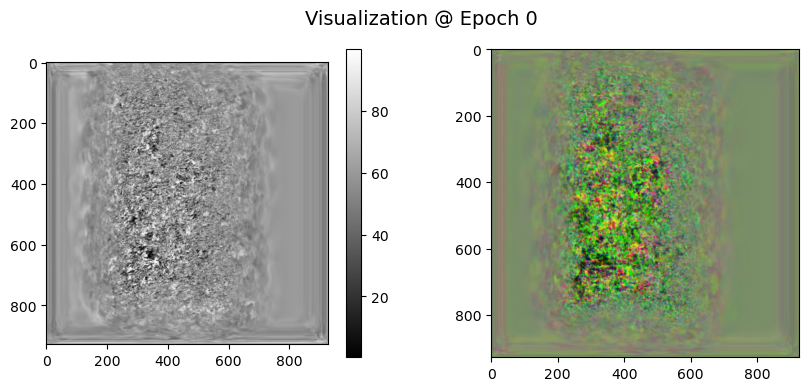

[101/6399] net0: 1.238e-02


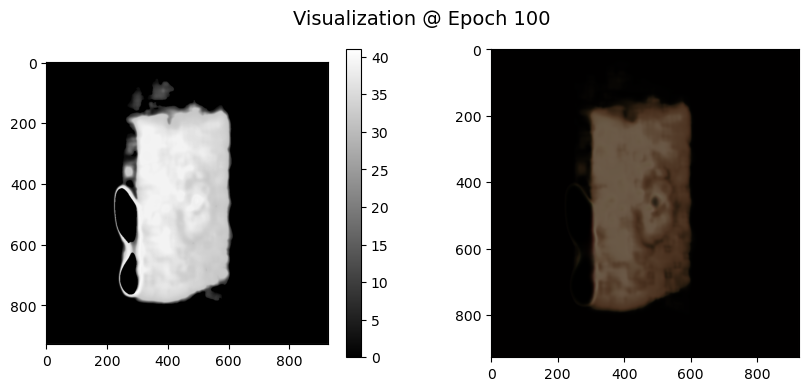

[201/6399] net0: 1.208e-02


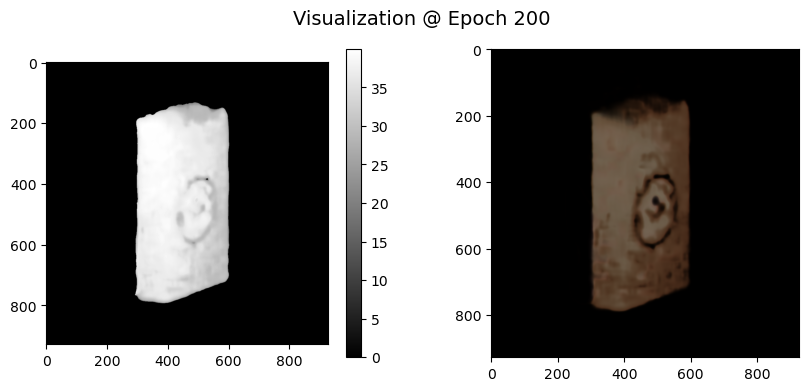

[301/6399] net0: 1.197e-02


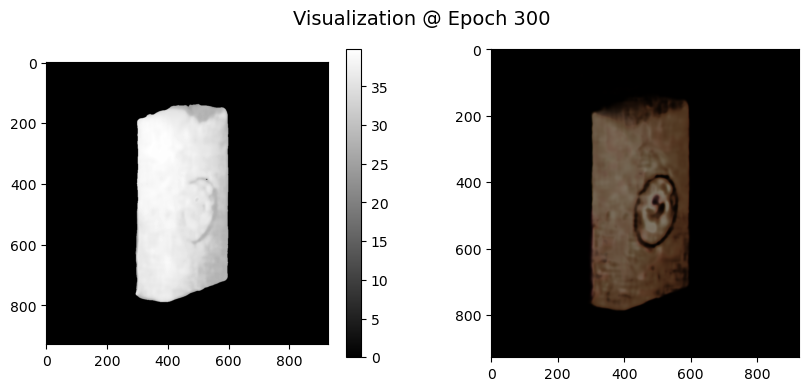

[401/6399] net0: 1.183e-02


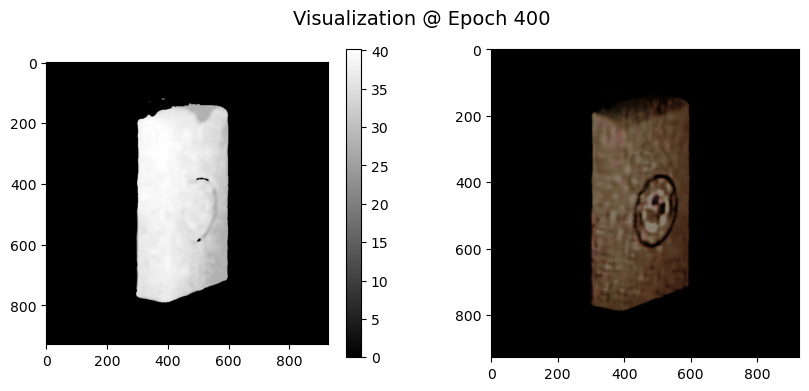

[501/6399] net0: 1.184e-02


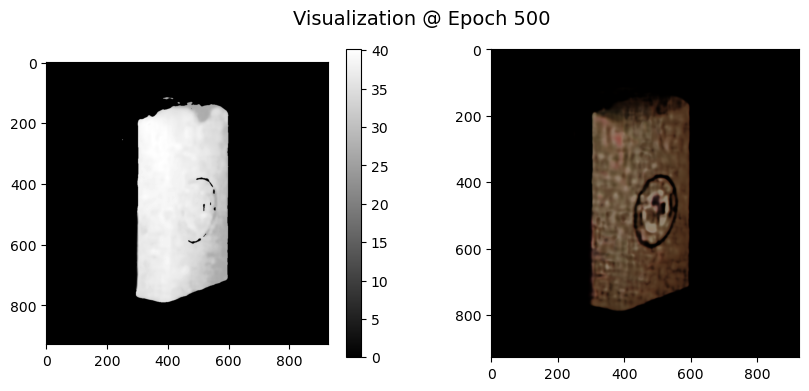

[601/6399] net0: 1.184e-02


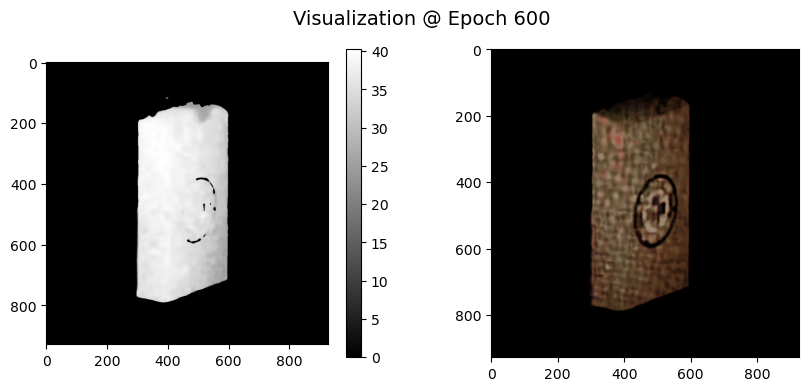

[701/6399] net0: 1.181e-02


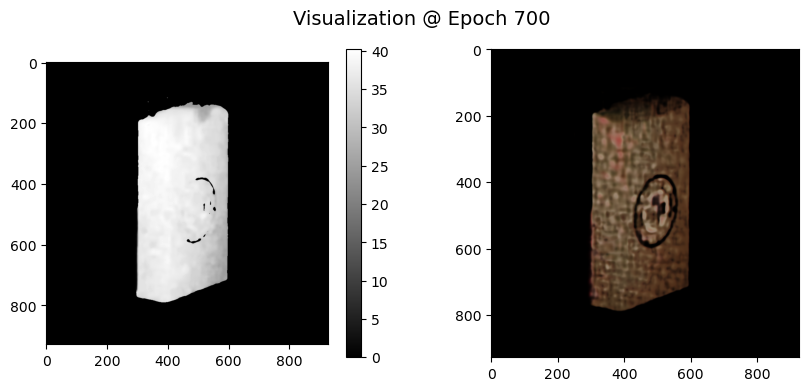

[801/6399] net0: 1.181e-02


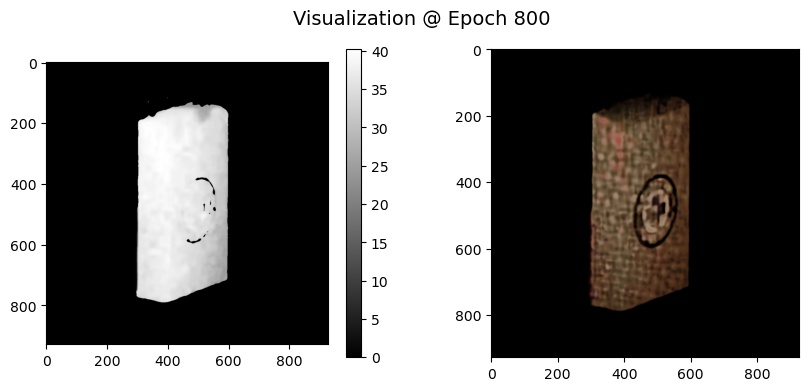

[901/6399] net0: 1.180e-02


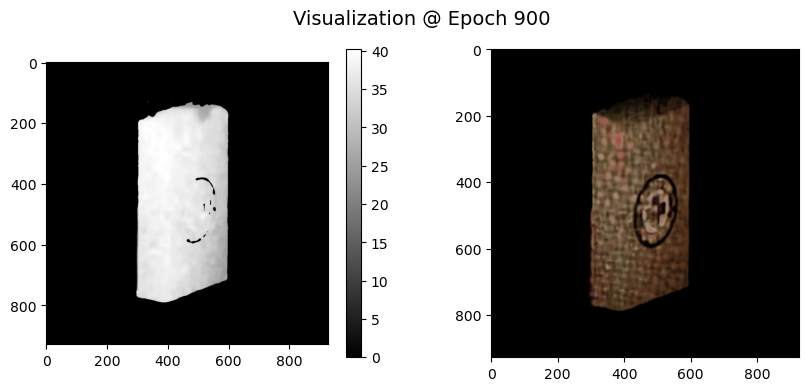

[1001/6399] net0: 1.187e-02


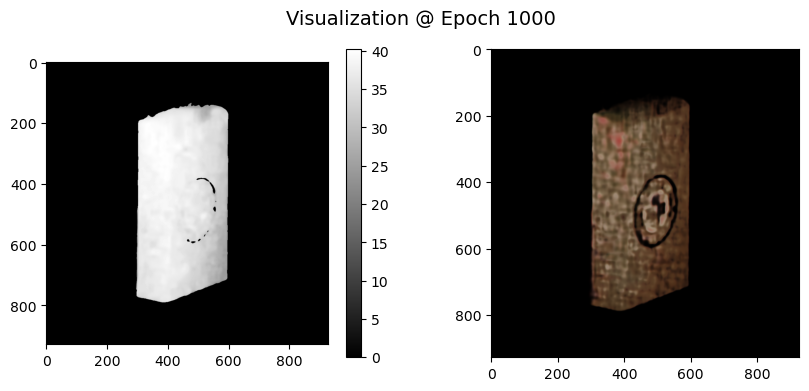

[1101/6399] net0: 1.186e-02


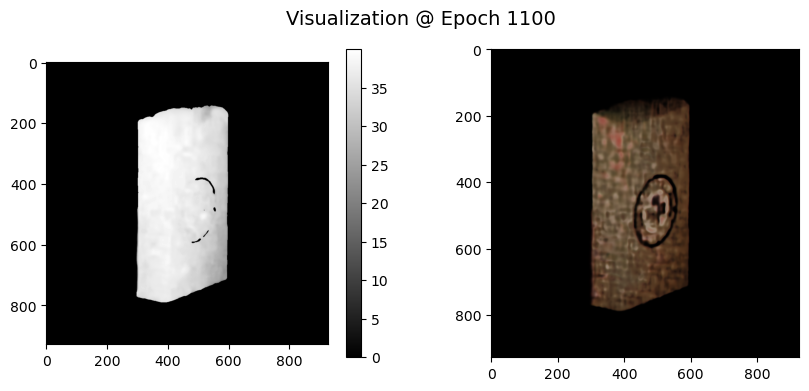

[1201/6399] net0: 1.186e-02


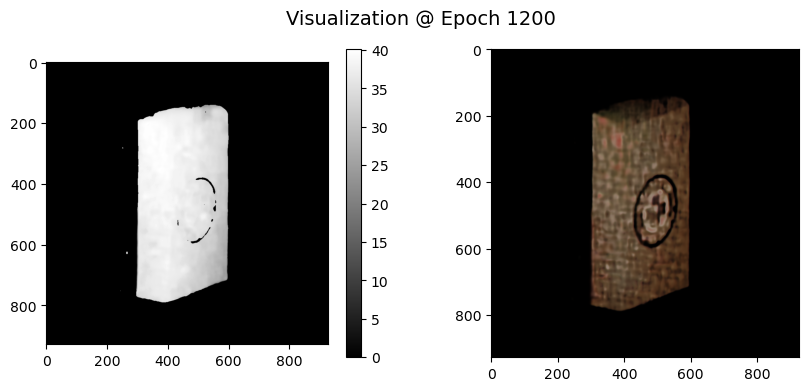

[1301/6399] net0: 1.192e-02


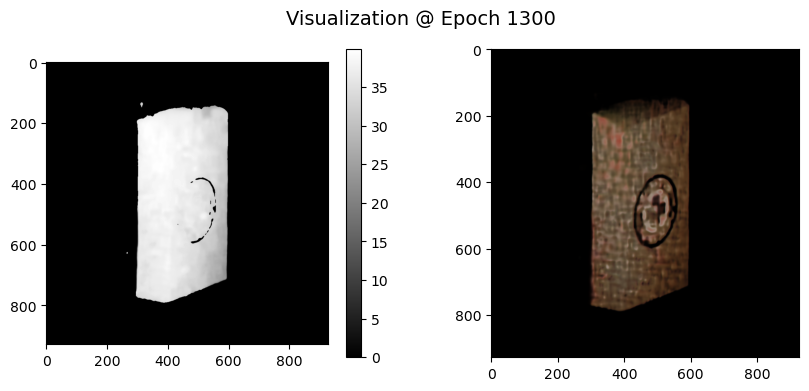

[1401/6399] net0: 1.186e-02


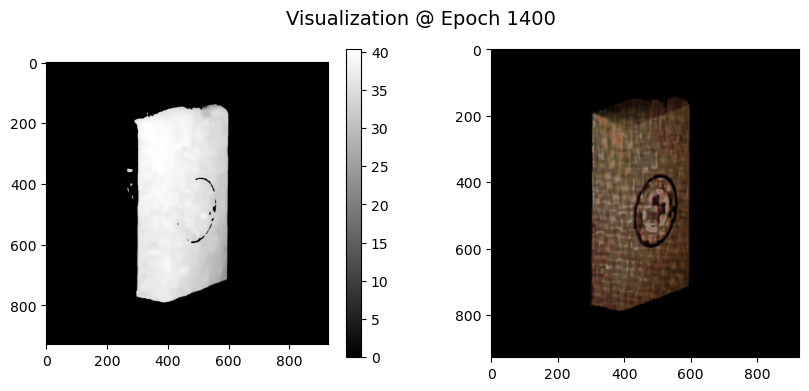

[1501/6399] net0: 1.182e-02


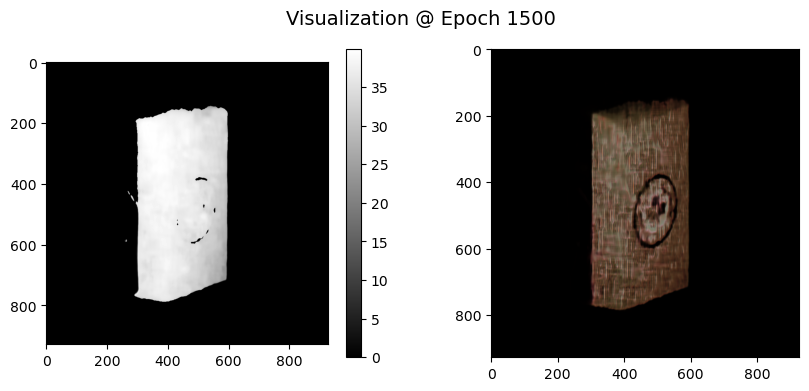

[1601/6399] net0: 1.126e-02


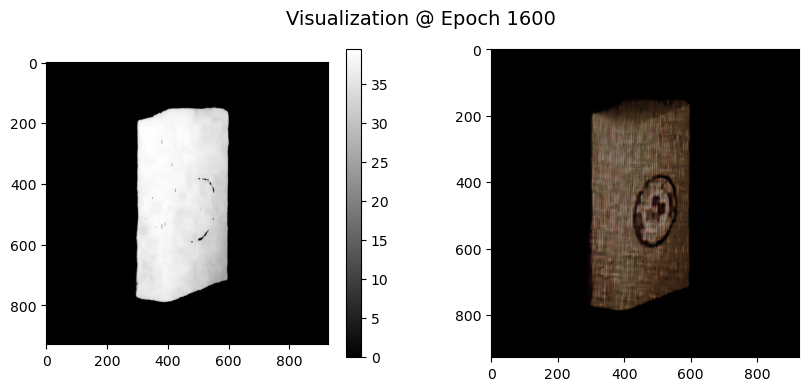

[1701/6399] net0: 1.058e-02


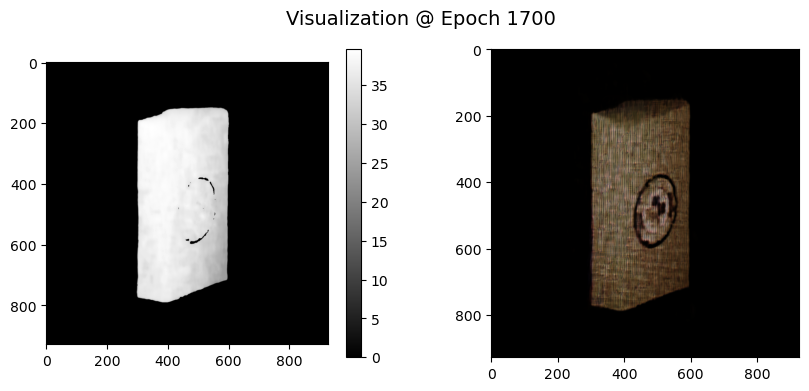

[1801/6399] net0: 1.017e-02


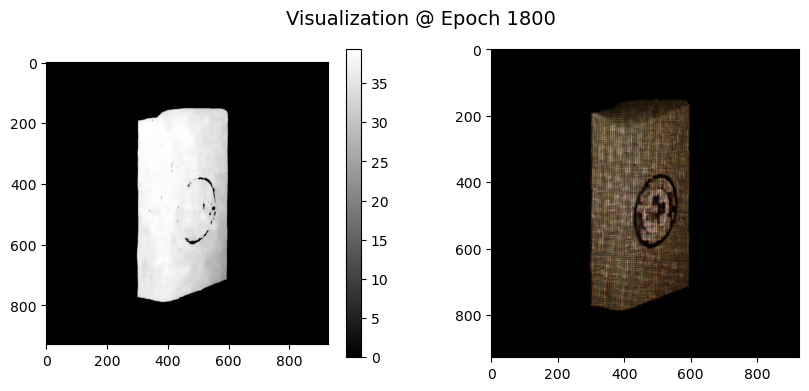

[1901/6399] net0: 1.026e-02


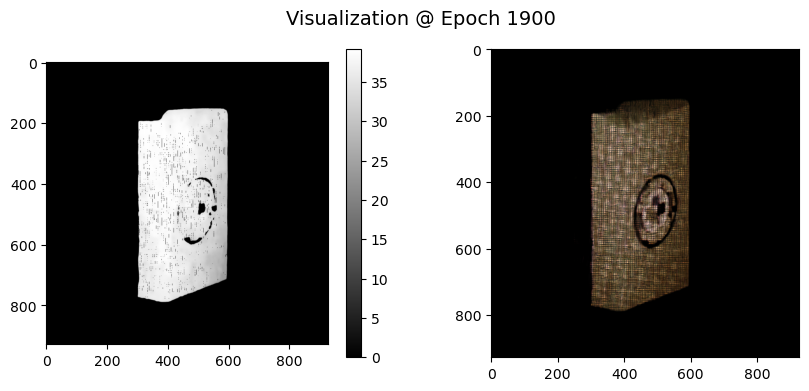

[2001/6399] net0: 1.142e-02


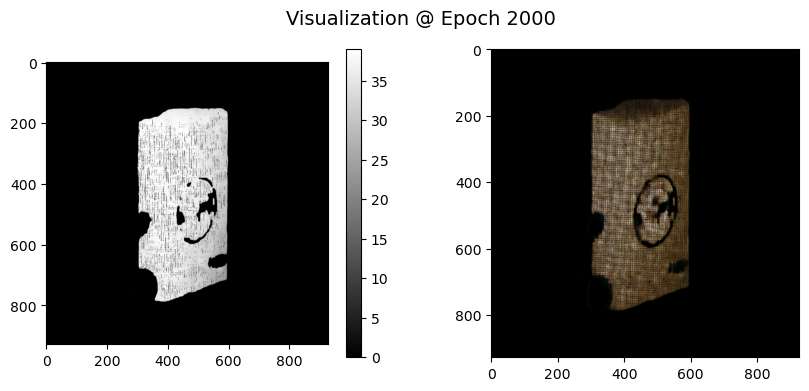

[2101/6399] net0: 1.190e-02


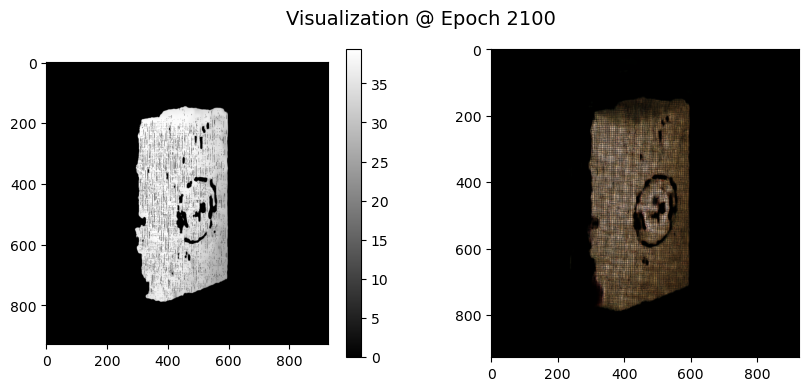

[2201/6399] net0: 1.116e-02


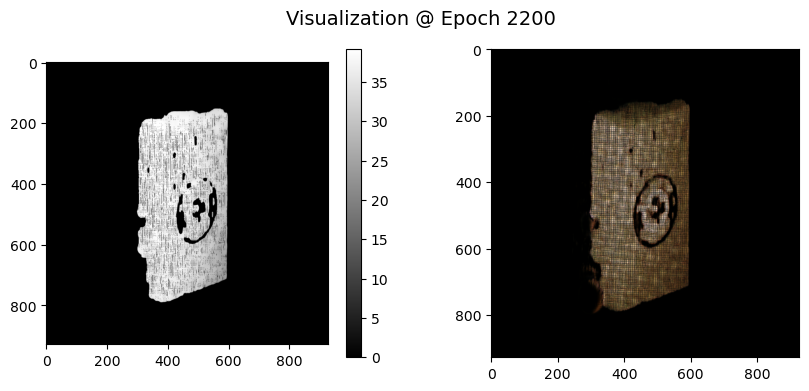

[2301/6399] net0: 1.149e-02


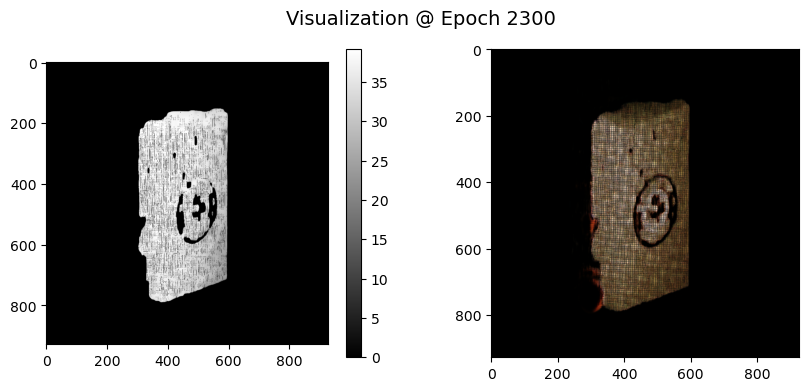

[2401/6399] net0: 1.148e-02


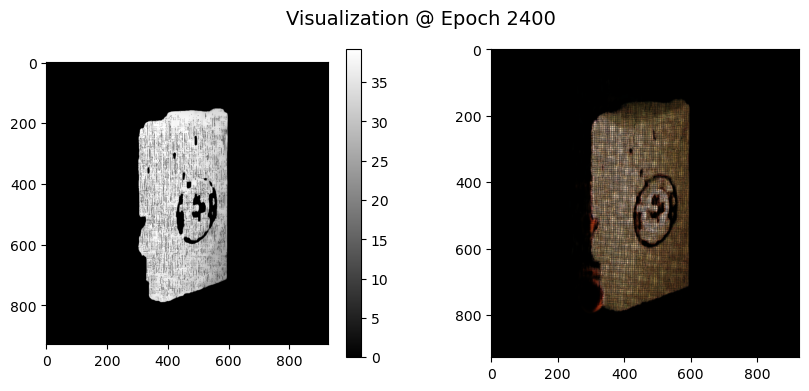

[2501/6399] net0: 1.145e-02


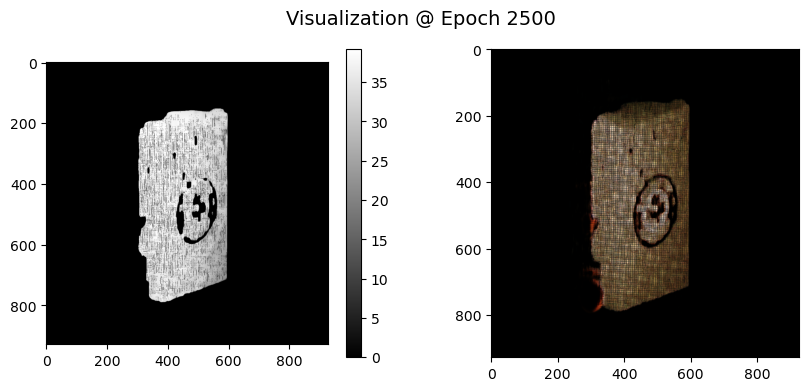

[2601/6399] net0: 1.182e-02


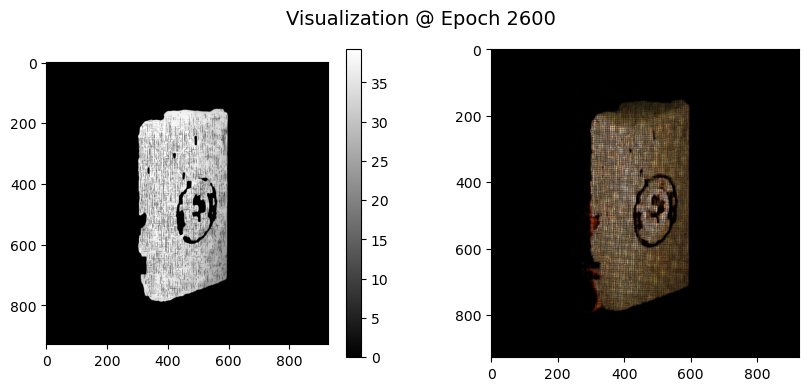

[2701/6399] net0: 1.154e-02


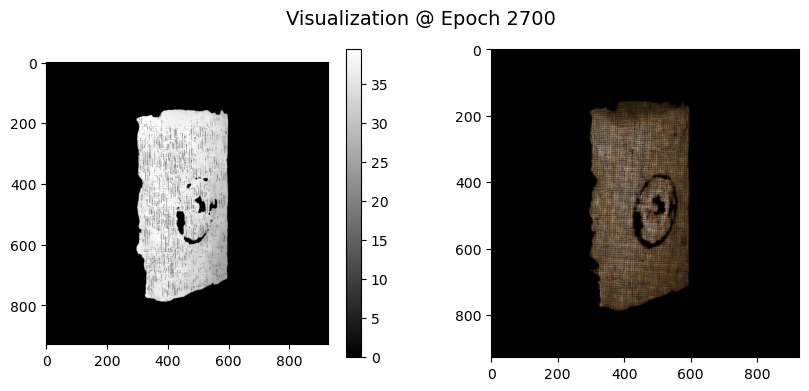

[2801/6399] net0: 1.192e-02


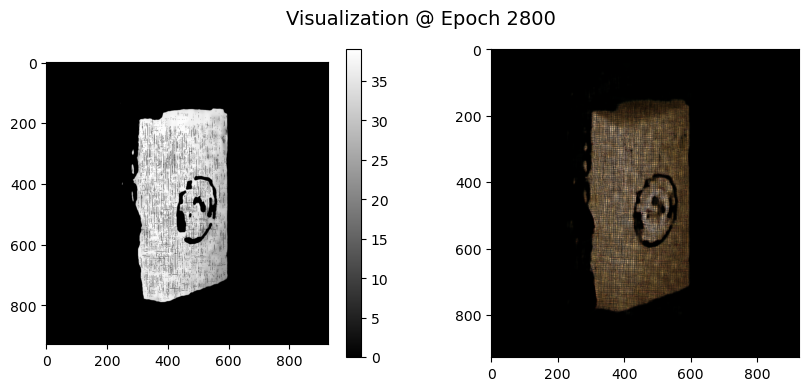

[2901/6399] net0: 1.137e-02


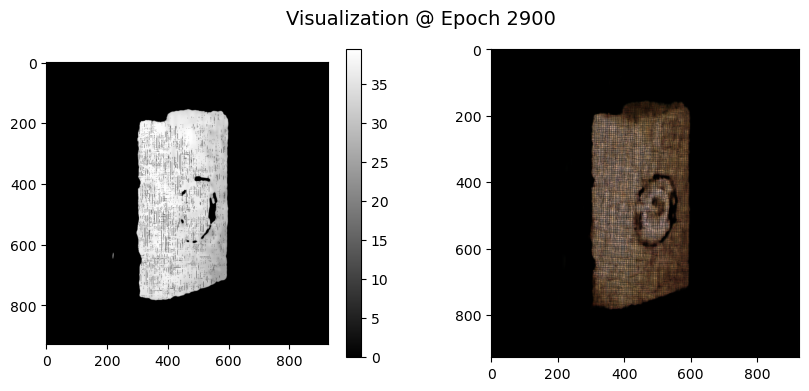

[3001/6399] net0: 1.269e-02


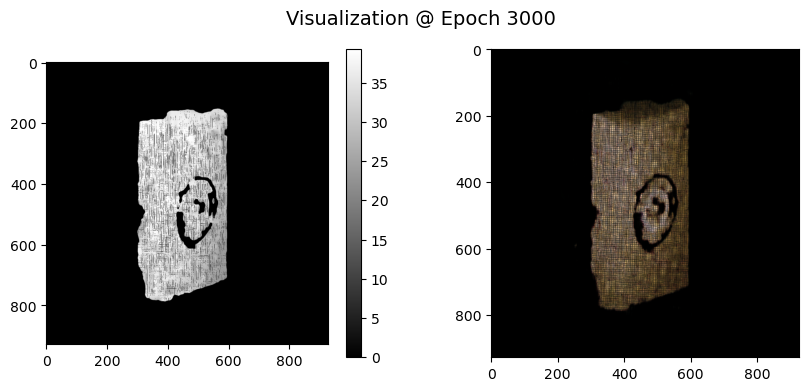

[3101/6399] net0: 1.188e-02


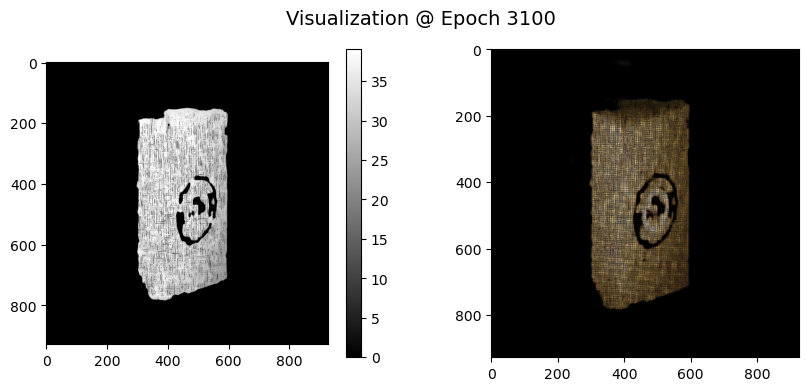

[3201/6399] net0: 1.219e-02


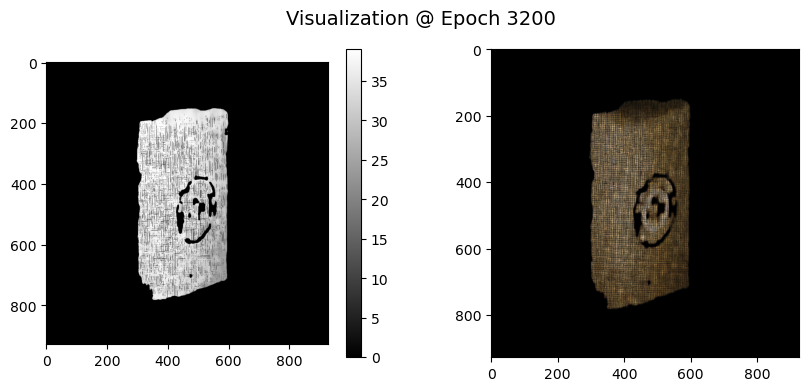

[3301/6399] net0: 1.222e-02


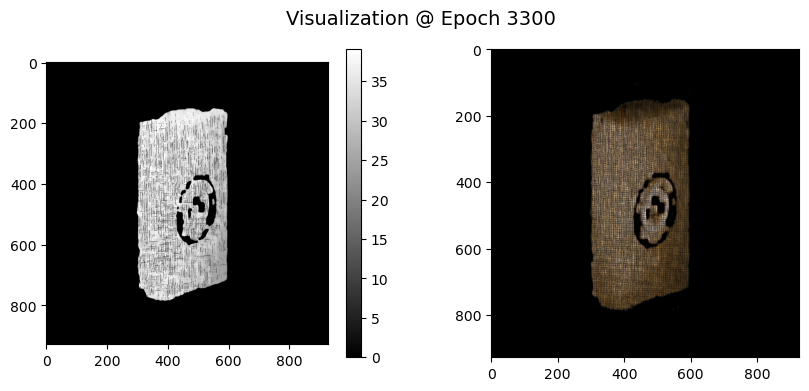

[3401/6399] net0: 1.237e-02


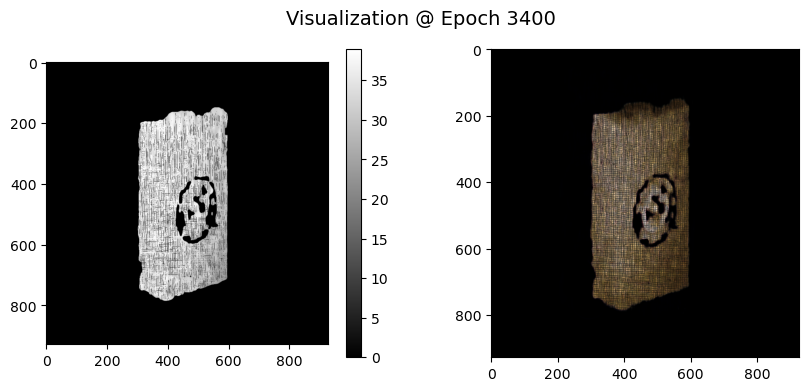

[3501/6399] net0: 1.263e-02


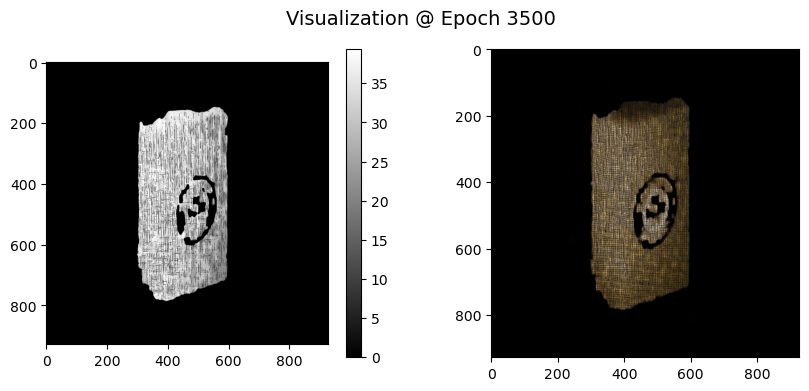

[3601/6399] net0: 1.278e-02


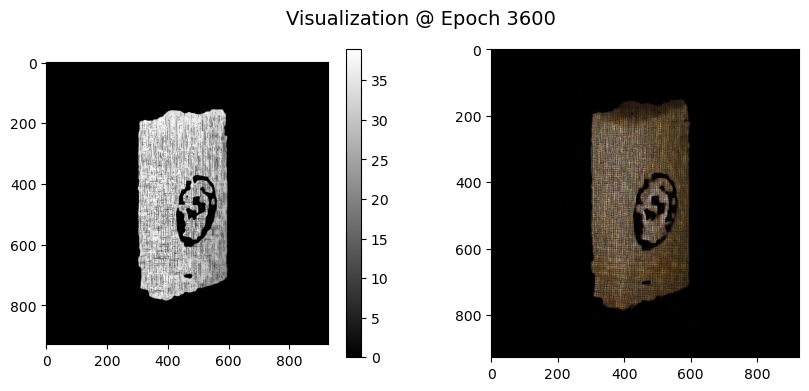

[3701/6399] net0: 1.248e-02


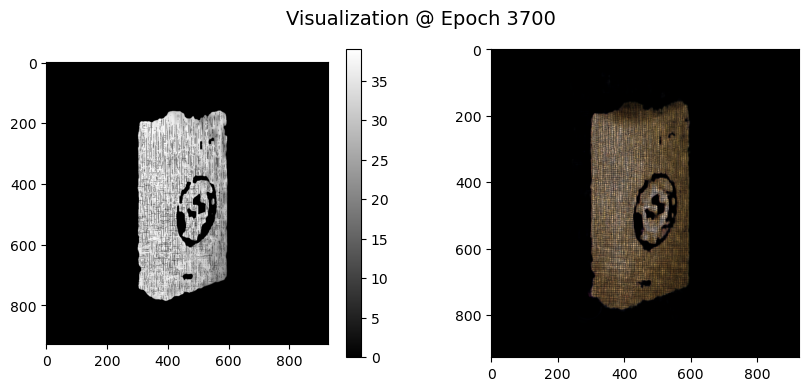

[3801/6399] net0: 1.257e-02


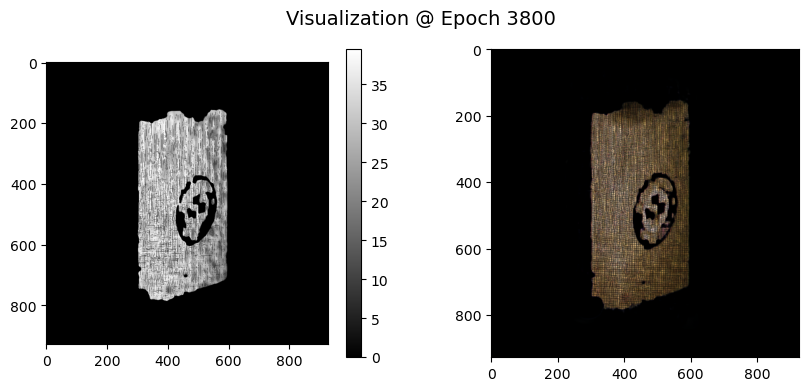

[3901/6399] net0: 1.249e-02


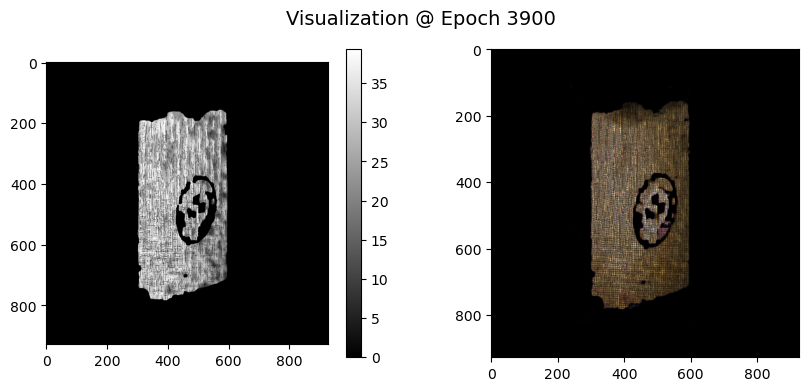

[4001/6399] net0: 1.247e-02


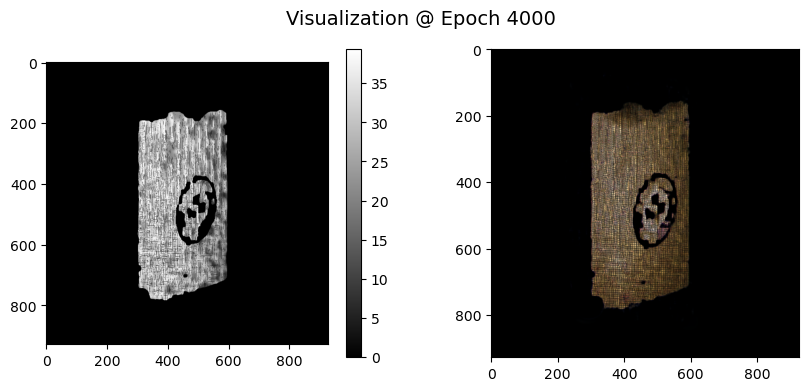

[4101/6399] net0: 1.246e-02


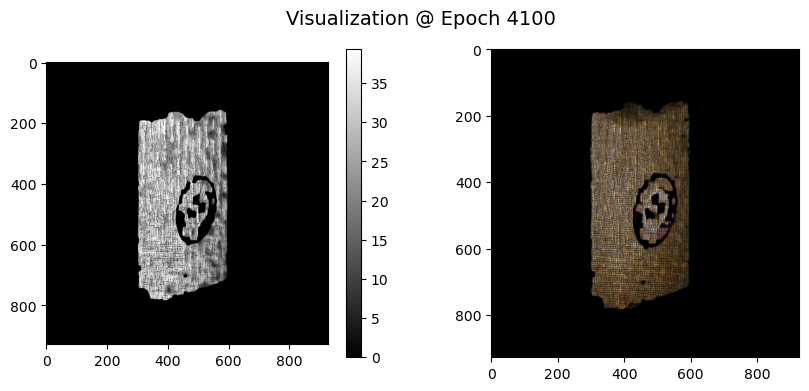

[4201/6399] net0: 1.274e-02


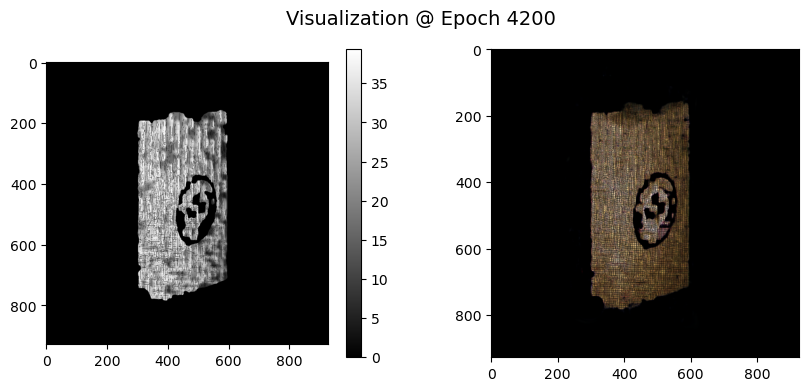

[4301/6399] net0: 1.305e-02


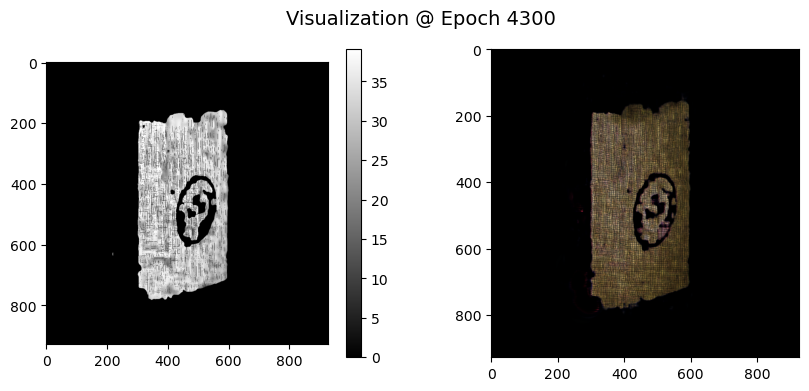

[4401/6399] net0: 1.231e-02


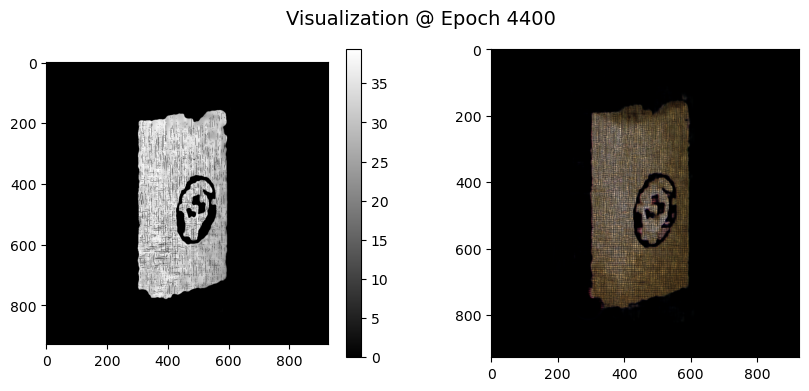

[4501/6399] net0: 1.282e-02


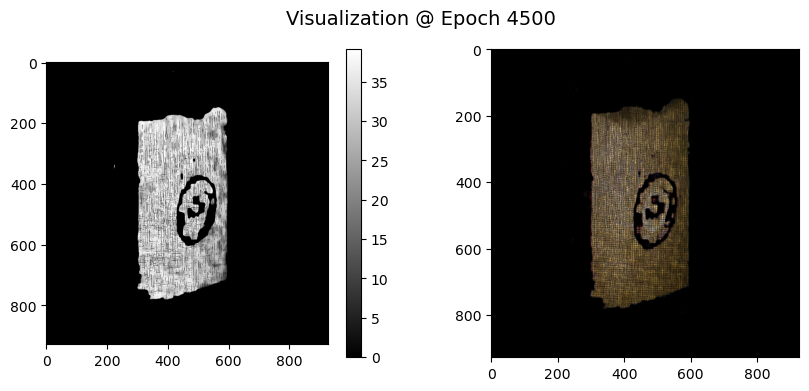

[4601/6399] net0: 1.047e-02


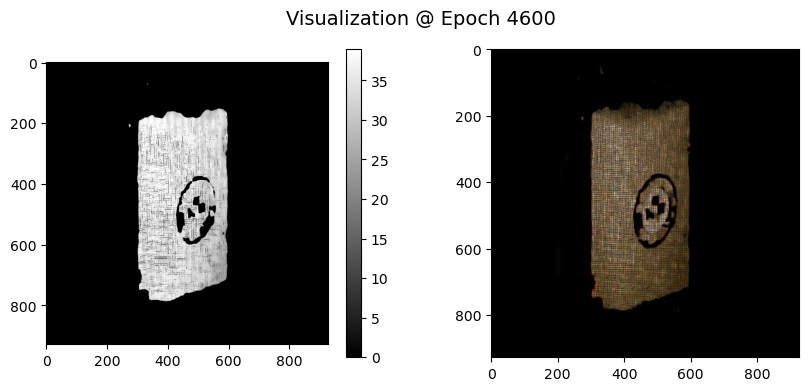

[4701/6399] net0: 1.273e-02


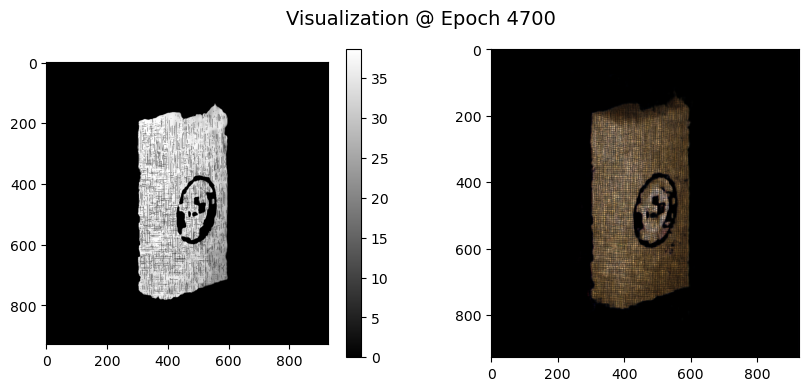

[4801/6399] net0: 1.180e-02


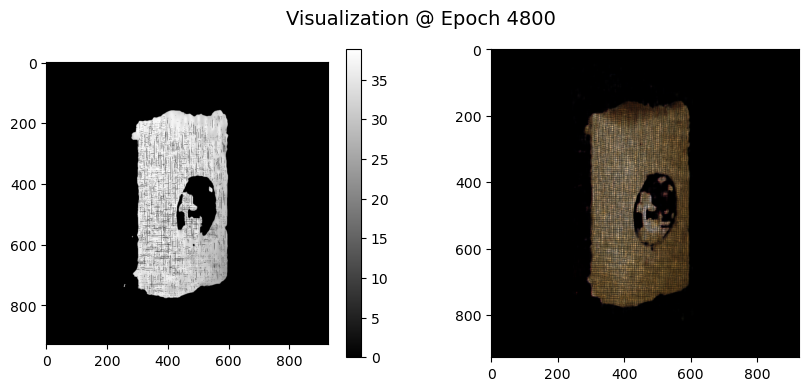

[4901/6399] net0: 1.274e-02


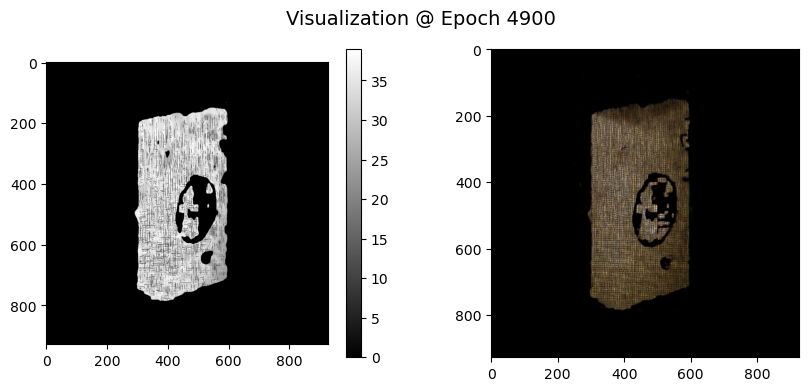

[5001/6399] net0: 1.203e-02


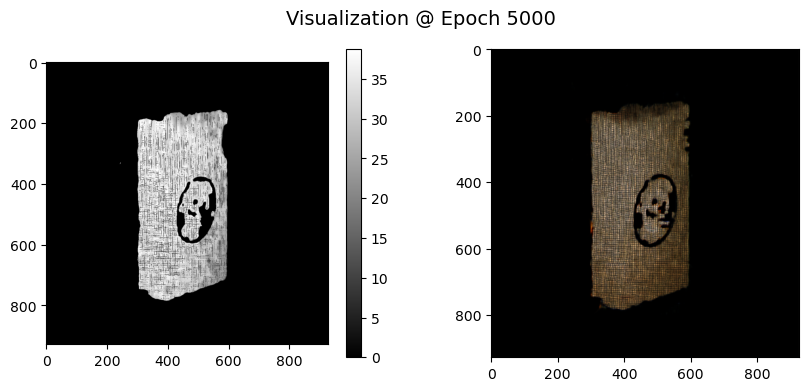

[5101/6399] net0: 1.047e-02


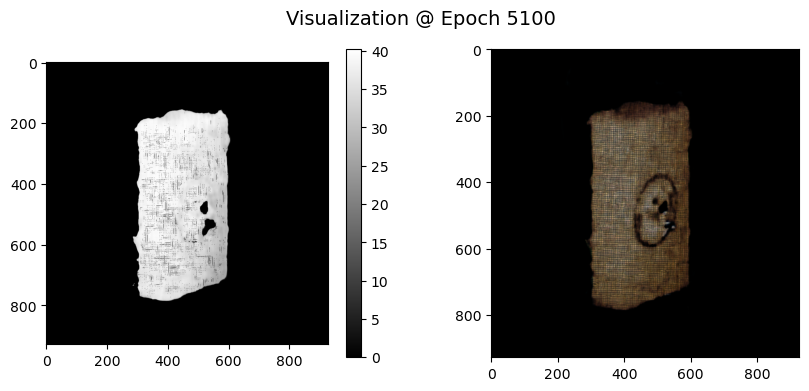

[5201/6399] net0: 1.242e-02


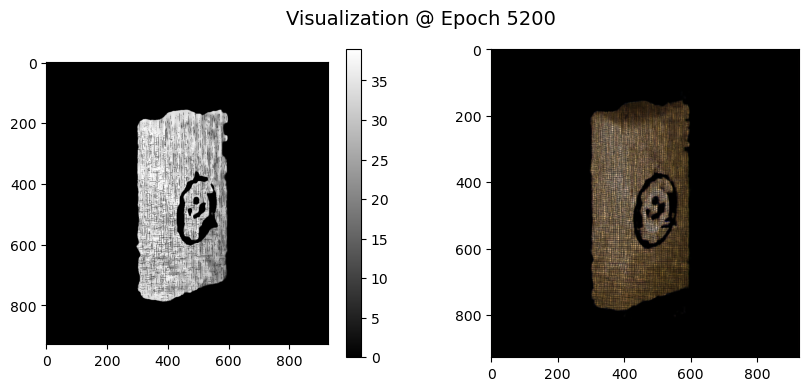

[5301/6399] net0: 1.246e-02


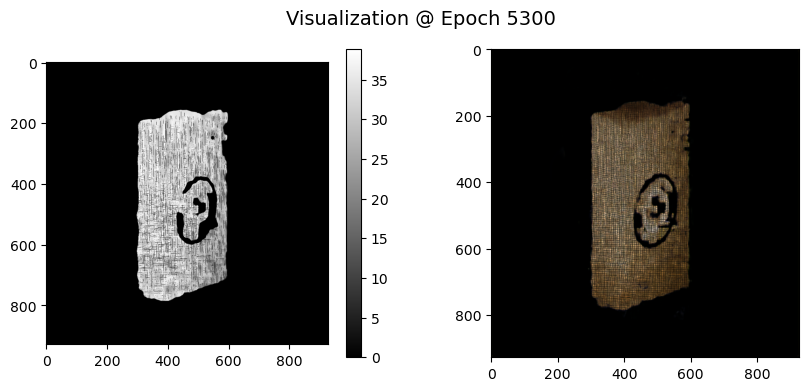

[5401/6399] net0: 1.246e-02


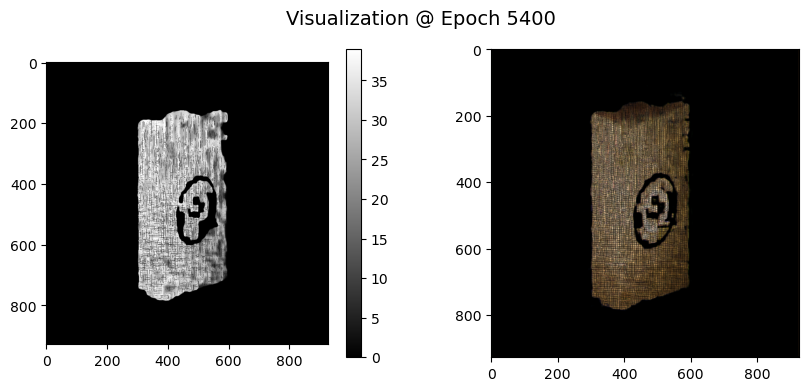

[5501/6399] net0: 1.236e-02


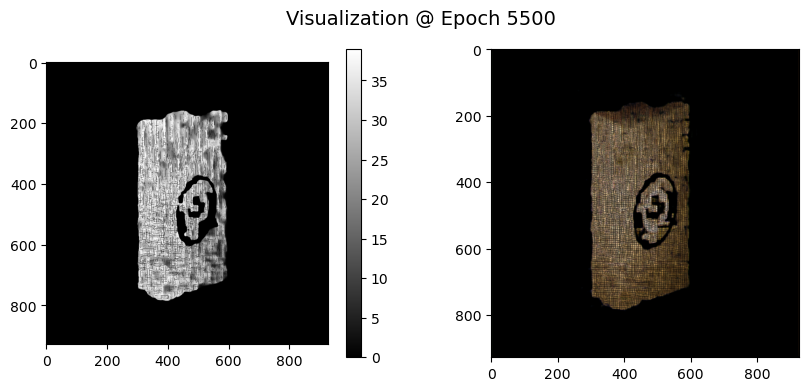

[5601/6399] net0: 1.234e-02


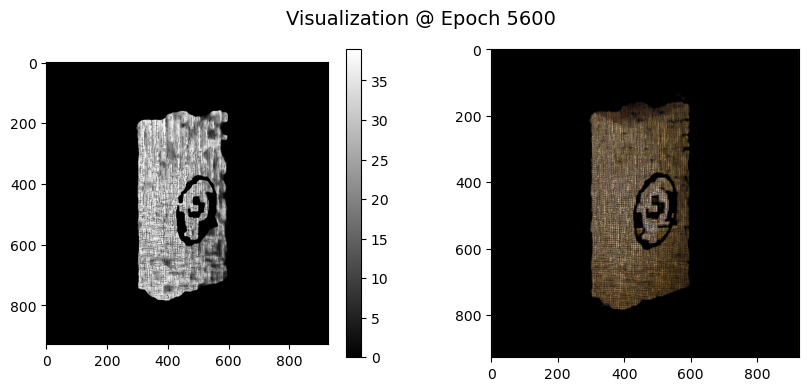

[5701/6399] net0: 1.240e-02


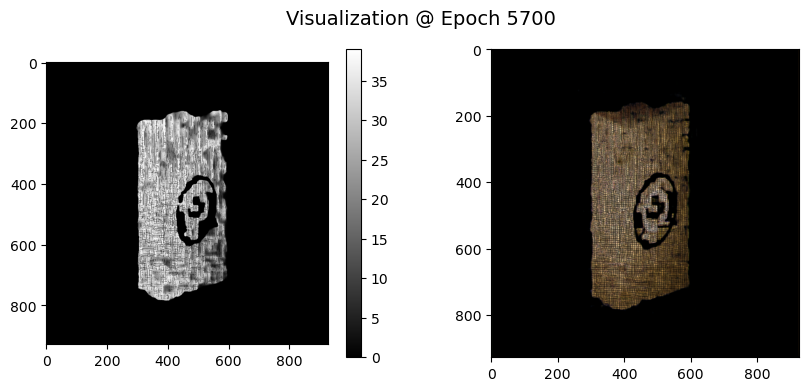

[5801/6399] net0: 1.290e-02


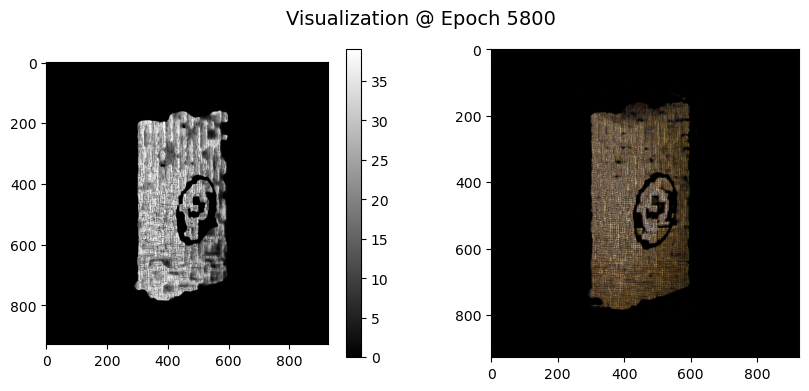

[5901/6399] net0: 1.284e-02


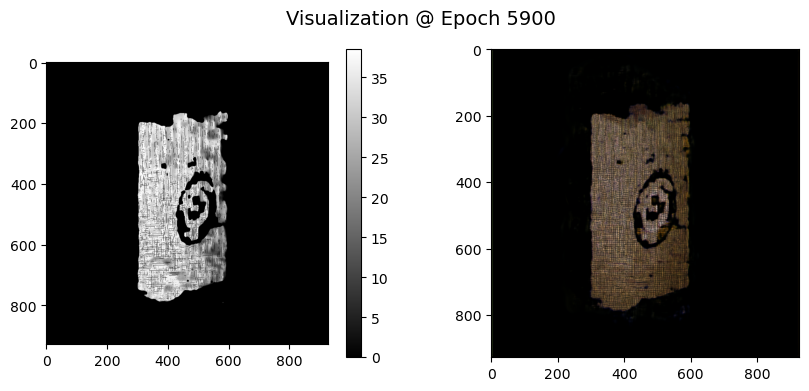

[6001/6399] net0: 1.236e-02


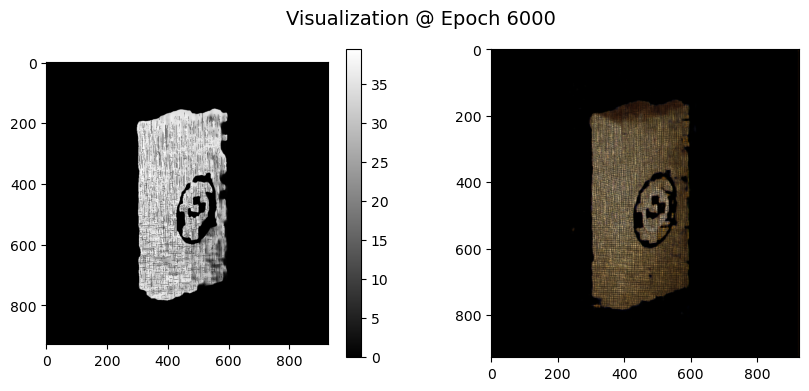

[6101/6399] net0: 1.250e-02


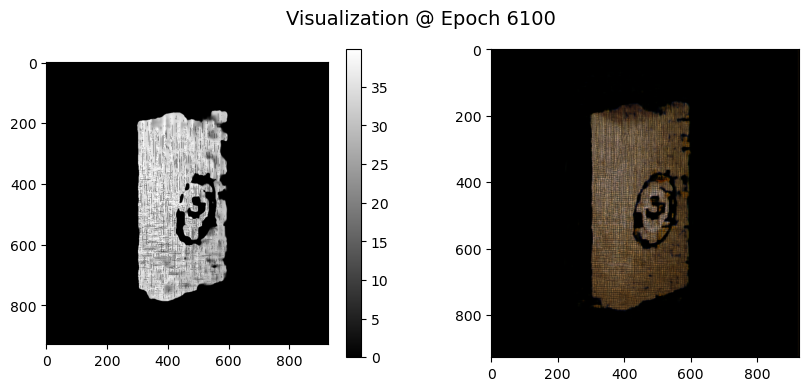

[6201/6399] net0: 1.179e-02


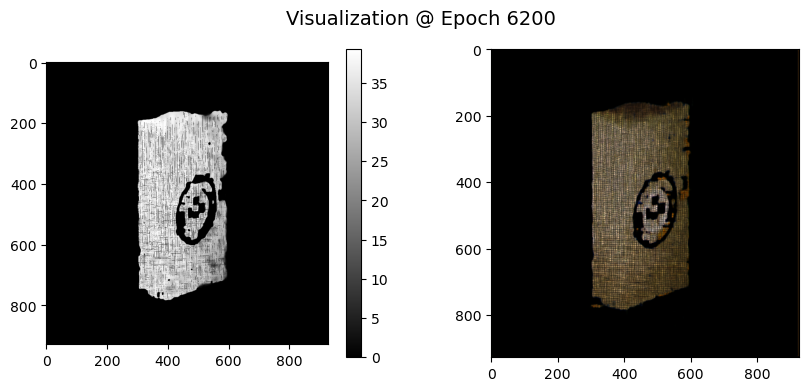

[6301/6399] net0: 1.312e-02


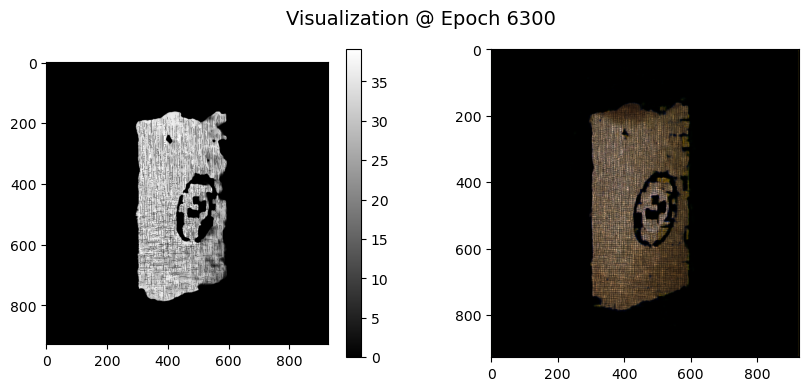

Training finished in 6017.2s


In [7]:
proj_img_sys = imager2

output_root = '../NN_train_results/' 
os.makedirs(output_root, exist_ok=True)
n_nets = 1

seeds = [42]
for seed in seeds:
    setup_seed(seed)
    # ========== ==========
    model = MultiChannelFusionNet(in_channels=3, base_channels=64).to(DEVICE)

    ParallelTrain = NetParallelTrain(base_model=model, n_nets=1, device=DEVICE)


    multi_model, loss_lists = ParallelTrain.train(
        measured_img=measured_img,
        proj_img_sys=proj_img_sys,
        pattern=pattern,
        extent_mm=extent_mm,
        num_epochs=int(3199*2+1),
        show_every=100,
        use_height_smooth=1,
        use_reflectance_smooth=0,
        msk_on=0,

        snapshot_every=None,
        snapshot_root=f'{output_root}/{seed}/',
    )


In [8]:
count_parameters(multi_model)

Total parameters:         75,163,684
Trainable parameters:     75,163,684
Non-trainable parameters: 0
--------------------------------------------------
Total model size:         286.73 MB
Trainable size:           286.73 MB
Non-trainable size:       0.00 MB
Trainable ratio:          100.00%


{'total_params': 75163684,
 'trainable_params': 75163684,
 'non_trainable_params': 0,
 'total_size_mb': 286.72669982910156,
 'trainable_size_mb': 286.72669982910156,
 'non_trainable_size_mb': 0.0}